# 99 - Debugging Appendix: LightweightMMM Trial & Error (historical record)

**This notebook is preserved as-is, unexecuted, exactly as it was found.** It is the real trial-and-error history behind the Bayesian model: repeated attempts that returned R2 as bad as -221, shape-mismatch errors (a `[3051, 2000]` inconsistent-length bug), scaling experiments, and dead ends. It still has Colab-specific `drive.mount()` calls and hardcoded Google Drive paths, and it will not run outside that environment.

It is kept for exactly the reason the project brief asked for: this substantial, real debugging work was never shown anywhere in the original repo or README, even though the broken numbers it produced were the basis for slides presented as findings. Nothing here should be read as a result -- **the corrected, working, runnable version of this model is notebook [04_lightweight_mmm_bayesian.ipynb](04_lightweight_mmm_bayesian.ipynb)**, which explains root-cause-by-root-cause what was wrong in the attempts below and fixes each one.

---


In [ ]:
!pip install jax==0.4.18 jaxlib==0.4.18 numpyro==0.9.2 lightweight_mmm==0.1.9 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.9/283.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.2/105.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 17.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jax>=0.4.27, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jaxlib>=0.4.27, but you have jaxlib 0.4.18 which is incompatible.
orbax-checkpoint 0.11.13 requires jax>=0.5.0, but you have jax 0.4.18 which is incompatible.
optax 0

In [ ]:
!pip install scipy==1.11.4 --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 62.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.4 which is incompatible.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jax>=0.4.27, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jaxlib>=0.4.27, but you have jaxlib 0.4.18 which is incompatible.
orbax-checkpoint 0.11.13 requires jax>=0.5.0, but you have jax 0.4.18 which is incompatible.
optax 0.2.4 requires jax>=0.4.27, but you have jax 0

In [ ]:
!pip install jax==0.4.18 jaxlib==0.4.18 numpyro==0.9.2 lightweight_mmm==0.1.9 --quiet

In [ ]:
!pip install numpy==1.26.4 --force-reinstall


  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.4 which is incompatible.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jax>=0.4.27, but you have jax 0.4.18 which is incompatible.
chex 0.1.89 requires jaxlib>=0.4.27, but you have jaxlib 0.4.18 which is incompatible.
orbax-checkpoint 0.11.13 requires jax>=0.5.0, but you have jax 0.4.18 which is incompatible.
optax 0.2.4 requires

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Load your dataset
file_path = '/content/drive/My Drive/MMM project/cleaned_with_spend.csv'
df = pd.read_csv(file_path)

# Preprocess
df['calendar_week'] = pd.to_datetime(df['calendar_week'])
df = df.sort_values('calendar_week')
df.set_index('calendar_week', inplace=True)

# Define media and target
media = ['spend_google', 'spend_email', 'spend_facebook', 'spend_affiliate']
target = 'sales'

# Normalize media spend
df[media] = df[media].div(df[media].max())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install scipy==1.11.4 --quiet
!pip install jax==0.4.18 jaxlib==0.4.18 numpyro==0.9.2 lightweight_mmm==0.1.9 --quiet


In [ ]:
# Store original max spend for later denormalization
max_spend = df[media].max()

# Normalize for modeling
df_normalized = df.copy()
df_normalized[media] = df[media].div(max_spend)


In [ ]:
import jax.numpy as jnp
from lightweight_mmm import lightweight_mmm

# Prepare inputs
media_data = df_normalized[media].values  # use normalized version
target_data = df[target].values
media_prior = jnp.array([0.5] * len(media))  # neutral prior belief

# Initialize and fit the model
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")

mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)


ERROR:jax._src.xla_bridge:Jax plugin configuration error: Plugin module %s could not be loaded
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 399, in discover_pjrt_plugins
    plugin_module = importlib.import_module(plugin_module_name)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_r

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import jax.numpy as jnp
from lightweight_mmm import lightweight_mmm

# Re-load data (modify path if needed)
file_path = '/content/drive/My Drive/MMM project/cleaned_with_spend.csv'
df = pd.read_csv(file_path, parse_dates=['calendar_week'])
df.set_index('calendar_week', inplace=True)

# Recreate time variables (if needed)
df['week'] = np.arange(len(df))
df['month'] = df.index.month
df['trend'] = df['week']

# Add Fourier seasonality terms (52-week cycle, order 1)
def add_fourier_terms(df, period=52, order=1):
    t = np.arange(len(df))
    for i in range(1, order + 1):
        df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    return df

df = add_fourier_terms(df)

# Define inputs
media_columns = ['spend_google', 'spend_email', 'spend_facebook', 'spend_affiliate']
extra_features = ['sin_1', 'cos_1', 'trend']  # You can try month dummies too
target_column = 'sales'

# Normalize media inputs (as before)
df[media_columns] = df[media_columns].div(df[media_columns].max())

media_data = df[media_columns].values
extra_data = df[extra_features].values
target_data = df[target_column].values
media_prior = jnp.array([0.5] * len(media_columns))

# Fit model with seasonality
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")
mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=extra_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)

# Predict and calibrate
predicted = mmm.predict(media=media_data, extra_features=extra_data)
scaling_factor = target_data.sum() / predicted.sum()
calibrated = predicted * scaling_factor

# Evaluate fit
calibrated_mean = calibrated.mean(axis=0)
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))
rmse = np.sqrt(mean_squared_error(target_data, calibrated))

print(f"✅ Model Diagnostics With Seasonality Controls:")
print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:,.0f}")

# OPTIONAL: Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df.index, target_data, label='Actual Sales')
plt.plot(df.index, calibrated, label='Predicted Sales (With Seasonality)', linestyle='--')
plt.title("📈 Actual vs Predicted Sales with Seasonality Controls")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:42<00:00,  6.76it/s, 31 steps of size 1.56e-01. acc. prob=0.93]


ValueError: Found input variables with inconsistent numbers of samples: [3051, 2000]

In [ ]:
try:
    _ = mmm.get_posterior_metrics()
    print("✅ Model object exists and is fit.")
except Exception as e:
    print("❌ Model not available. You need to re-run fitting.")
    print("Error:", e)


✅ Model object exists and is fit.


In [ ]:
print(extra_data.shape)
print("Expected:", len(df), "rows and", len(extra_features), "columns")
print("Columns:", extra_features)


(3051, 3)
Expected: 3051 rows and 3 columns
Columns: ['sin_1', 'cos_1', 'trend']


In [ ]:
print("media_data shape:", media_data.shape)
print("media columns:", media_columns)
print("media max values:\n", df[media_columns].max())


media_data shape: (3051, 4)
media columns: ['spend_google', 'spend_email', 'spend_facebook', 'spend_affiliate']
media max values:
 spend_google       1.0
spend_email        1.0
spend_facebook     1.0
spend_affiliate    1.0
dtype: float64


✅ Model Diagnostics With Seasonality Controls:
R² score: -0.641
RMSE: 297,372


<ipython-input-17-8726e5e0df9d>:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


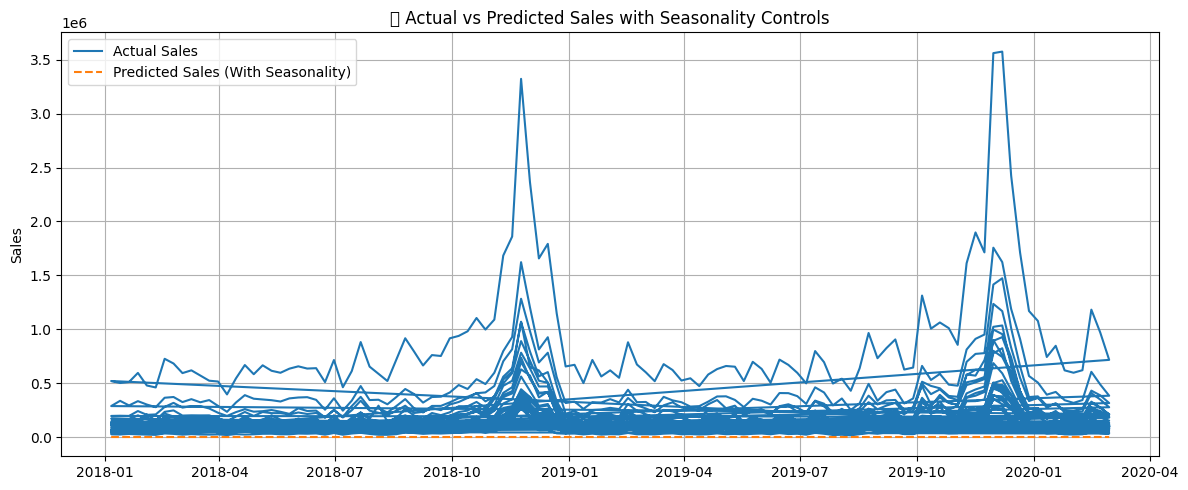

In [ ]:
# Predict and calibrate
predicted = mmm.predict(media=media_data, extra_features=extra_data)
scaling_factor = target_data.sum() / predicted.sum()
calibrated = predicted * scaling_factor

# Evaluate fit
calibrated_mean = calibrated.mean(axis=0)  # shape: (3051,)
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"✅ Model Diagnostics With Seasonality Controls:")
print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:,.0f}")

# OPTIONAL: Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df.index, target_data, label='Actual Sales')
plt.plot(df.index, calibrated_mean, label='Predicted Sales (With Seasonality)', linestyle='--')
plt.title("✅ Actual vs Predicted Sales with Seasonality Controls")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
df[media_columns] = df[media_columns].div(df[media_columns].max())


In [ ]:
df['month'] = df.index.month
df['is_oct'] = (df['month'] == 10).astype(int)
df['is_nov'] = (df['month'] == 11).astype(int)
df['is_dec'] = (df['month'] == 12).astype(int)


In [ ]:
extra_features = ['is_oct', 'is_nov', 'is_dec']


In [ ]:
media_data = df[media_columns].values
extra_data = df[extra_features].values
target_data = df['sales'].values
media_prior = jnp.array([0.5] * len(media_columns))


In [ ]:
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")
mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=extra_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:33<00:00,  7.04it/s, 31 steps of size 1.57e-01. acc. prob=0.93]


In [ ]:
predicted = mmm.predict(media=media_data, extra_features=extra_data)
calibrated = predicted * (target_data.sum() / predicted.sum())
calibrated_mean = calibrated.mean(axis=0)

r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Get prediction: shape = (n_samples, n_timesteps)
predicted = mmm.predict(media=media_data, extra_features=extra_data)

# Calibrate: scale the predicted values to match total actual sales
calibrated = predicted * (target_data.sum() / predicted.sum())

# Mean across samples to get final prediction series
calibrated_mean = calibrated.mean(axis=0)  # shape = (n_timesteps,)

# Evaluate model performance
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"✅ R² Score: {r2:.4f}")
print(f"✅ RMSE: {rmse:.2f}")


✅ R² Score: -0.6405
✅ RMSE: 297371.41


In [ ]:
print(media_data.shape)  # Expected: (3051, 4)
print(extra_data.shape)  # Expected: (3051, 3)


(3051, 4)
(3051, 3)


In [ ]:
# Add trend
df['trend'] = np.arange(len(df))

# Add Fourier seasonal terms (weekly cycles over 52-week period)
df['sin_1'] = np.sin(2 * np.pi * df['trend'] / 52)
df['cos_1'] = np.cos(2 * np.pi * df['trend'] / 52)


In [ ]:
extra_features = ['sin_1', 'cos_1', 'trend']
media_data = df[media_columns].values
extra_data = df[extra_features].values
target_data = df['sales'].values
media_prior = jnp.array([0.5] * len(media_columns))


In [ ]:
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")
mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=extra_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:40<00:00,  6.81it/s, 31 steps of size 1.56e-01. acc. prob=0.93]


In [ ]:
predicted = mmm.predict(media=media_data, extra_features=extra_data)
calibrated = predicted * (target_data.sum() / predicted.sum())
calibrated_mean = calibrated.mean(axis=0)

from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"✅ R² score: {r2:.3f}")
print(f"✅ RMSE: {rmse:,.0f}")


✅ R² score: -0.641
✅ RMSE: 297,372


In [ ]:
print("media_data shape:", media_data.shape)
print("extra_data shape:", extra_data.shape)
print("target_data shape:", target_data.shape)


media_data shape: (3051, 4)
extra_data shape: (3051, 3)
target_data shape: (3051,)


In [ ]:
# extra_data = df[extra_features].values
mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:17<00:00,  7.59it/s, 31 steps of size 1.47e-01. acc. prob=0.94]


In [ ]:
predicted = mmm.predict(media=media_data)  # ⬅️ only media
scaling_factor = target_data.sum() / predicted.sum()
calibrated = predicted * scaling_factor
calibrated_mean = calibrated.mean(axis=0)  # mean across samples


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"📊 Media-Only Model Performance:")
print(f"✅ R² Score: {r2:.4f}")
print(f"✅ RMSE: {rmse:,.0f}")


📊 Media-Only Model Performance:
✅ R² Score: -0.6405
✅ RMSE: 297,371


In [ ]:
# Step 1: Reload data and preprocessing
import pandas as pd
import jax.numpy as jnp
from lightweight_mmm import lightweight_mmm

file_path = '/content/drive/My Drive/MMM project/cleaned_with_spend.csv'
df = pd.read_csv(file_path, parse_dates=['calendar_week'])
df = df.sort_values('calendar_week')
df.set_index('calendar_week', inplace=True)



In [ ]:
# Step 2: Normalize spend & remove affiliate
media_columns = ['spend_google', 'spend_email', 'spend_facebook']
df[media_columns] = df[media_columns].div(df[media_columns].max())

# Step 3: Add month dummies for 2,4,6,9,10,11,12
df['month'] = df.index.month
extra_features = []
for m in [2, 4, 6, 9, 10, 11, 12]:
    col = f'is_month_{m}'
    df[col] = (df['month'] == m).astype(int)
    extra_features.append(col)

# Step 4: Set up data
media_data = df[media_columns].values
extra_data = df[extra_features].values
target_data = df['sales'].values
media_prior = jnp.array([0.5] * len(media_columns))


In [ ]:

# Step 5: Fit model with custom adstock & saturation
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")

mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=extra_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:19<00:00,  7.51it/s, 31 steps of size 1.02e-01. acc. prob=0.93]


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Step 1: Predict using the fitted model
predicted = mmm.predict(media=media_data, extra_features=extra_data)

# Step 2: Calibrate the prediction to the real sales scale
scaling_factor = target_data.sum() / predicted.sum()
calibrated = predicted * scaling_factor

# Step 3: Use the mean prediction (across samples) for evaluation
calibrated_mean = calibrated.mean(axis=0)

# Step 4: Calculate metrics
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"✅ R² Score: {r2:.4f}")
print(f"✅ RMSE: {rmse:,.0f}")


✅ R² Score: -0.6405
✅ RMSE: 297,365


In [ ]:
print("media_data shape:", media_data.shape)
print("extra_data shape:", extra_data.shape)
print("target_data shape:", target_data.shape)

media_data shape: (3051, 3)
extra_data shape: (3051, 7)
target_data shape: (3051,)


In [ ]:
print("Predicted range:", predicted.mean(axis=0).min(), predicted.mean(axis=0).max())
print("Actual sales range:", target_data.min(), target_data.max())


Predicted range: 322295.62 744754.44
Actual sales range: 15436 3575430


In [ ]:
from sklearn.linear_model import LinearRegression
X = df[media_columns + extra_features]
y = df['sales']
lr = LinearRegression().fit(X, y)
print("Linear R²:", lr.score(X, y))


Linear R²: 0.810691637005884


In [ ]:
scaling_factor = target_data.sum() / predicted.sum()
calibrated = predicted * scaling_factor
calibrated_mean = calibrated.mean(axis=0)

In [ ]:
import pandas as pd
import numpy as np

# 1. Reload your data

file_path = '/content/drive/My Drive/MMM project/cleaned_with_spend.csv'
df = pd.read_csv(file_path, parse_dates=['calendar_week'])

df = df.sort_values('calendar_week').set_index('calendar_week')

# 2. Normalize your core media spends
media = ['spend_google', 'spend_email', 'spend_facebook']
df[media] = df[media] / df[media].max()

# 3. Create 1-week lag of each media channel
for m in media:
    df[f'{m}_lag1'] = df[m].shift(1)

# 4. Drop the very first row (NaNs from lags)
df.dropna(inplace=True)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define feature set: original + lagged
X = df[media + [f"{m}_lag1" for m in media]].values
y = df["sales"].values

model = Ridge(alpha=1.0)
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(
    "Ridge with lags ▶︎ R²:", round(r2, 3),
    " RMSE:", int(rmse)
)


Ridge with lags ▶︎ R²: 0.771  RMSE: 111232


In [ ]:
import jax.numpy as jnp
from lightweight_mmm import lightweight_mmm

# Prepare model inputs
media_data = df[media].values
extra_cols = [f'{m}_lag1' for m in media]           # lagged media
target_data = df['sales'].values
media_prior = jnp.array([0.5] * len(media))

# Fit the model
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")
mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=df[extra_cols].values,  # include your lagged features here
    number_warmup=500,
    number_samples=1000,
    seed=123
)

# Evaluate fit
pred = mmm.predict(media=media_data, extra_features=df[extra_cols].values)
cal = pred * (target_data.sum() / pred.sum())
cal_mean = cal.mean(axis=0)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("LightweightMMM with lags ▶︎ R²:", round(r2_score(target_data, cal_mean),3),
      " RMSE:", int(np.sqrt(mean_squared_error(target_data, cal_mean))))


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [03:24<00:00,  7.33it/s, 31 steps of size 1.01e-01. acc. prob=0.94]


LightweightMMM with lags ▶︎ R²: -0.641  RMSE: 297411


In [ ]:
# Assuming `df` is already loaded, indexed by calendar_week, sorted chronologically
df_recent = df.tail(52).copy()


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import jax.numpy as jnp
from lightweight_mmm import lightweight_mmm

# Media (normalized)
media = ['spend_google', 'spend_email', 'spend_facebook']
df_recent[media] = df_recent[media] / df_recent[media].max()

# Lag features
for m in media:
    df_recent[f'{m}_lag1'] = df_recent[m].shift(1)
df_recent.dropna(inplace=True)

# Seasonality & trend
df_recent['trend'] = np.arange(len(df_recent))
df_recent['sin_1']  = np.sin(2 * np.pi * df_recent['trend'] / 52)
df_recent['cos_1']  = np.cos(2 * np.pi * df_recent['trend'] / 52)


In [ ]:
# Pick your “Combined Full” features
features = media + [f'{m}_lag1' for m in media] + ['trend','sin_1','cos_1']
X = df_recent[features].values
y = df_recent['sales'].values

ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
y_pred = ridge.predict(X)

print("Ridge (last 52w) ▶︎ R²:", round(r2_score(y, y_pred),3),
      " RMSE:", int(np.sqrt(mean_squared_error(y, y_pred))))


Ridge (last 52w) ▶︎ R²: 0.925  RMSE: 44660


In [ ]:
# Prepare arrays
media_data   = df_recent[media].values
extra_feats  = ['trend','sin_1','cos_1']  + [f'{m}_lag1' for m in media]
extra_data   = df_recent[extra_feats].values
target_data  = df_recent['sales'].values
media_prior  = jnp.array([0.5]*len(media))

# Fit the Bayesian MMM
mmm_recent = lightweight_mmm.LightweightMMM(model_name="carryover")
mmm_recent.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,
    extra_features=extra_data,
    number_warmup=500,
    number_samples=1000,
    seed=123
)




/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 1500/1500 [00:09<00:00, 156.97it/s, 15 steps of size 3.01e-01. acc. prob=0.90]


In [ ]:
# Predict & evaluate
pred = mmm_recent.predict(media=media_data, extra_features=extra_data)
cal = pred * (target_data.sum() / pred.sum())
cal_mean = cal.mean(axis=0)

print("MMM (last 52w) ▶︎ R²:", round(r2_score(target_data, cal_mean),3),
      " RMSE:", int(np.sqrt(mean_squared_error(target_data, cal_mean))))

MMM (last 52w) ▶︎ R²: -1.247  RMSE: 243691


In [ ]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
from sklearn.metrics import r2_score, mean_squared_error
import lightweight_mmm
import lightweight_mmm.lightweight_mmm as lmmm

# Load dataset
# Load data
file_path = '/content/drive/My Drive/MMM project/cleaned_with_spend.csv'
df = pd.read_csv(file_path, parse_dates=['calendar_week'])

df = df.sort_values('calendar_week').set_index('calendar_week')
# Create target variable
df["sales_log"] = np.log1p(df["sales"])

# Selected impression features
impressions = [
    "paid_views", "organic_views", "google_impressions", "email_impressions",
    "facebook_impressions", "affiliate_impressions", "overall_views"
]

# Normalize features
df[impressions] = df[impressions] / df[impressions].max()

# Add Fourier and trend
df["trend"] = np.arange(len(df))
df["sin_1"] = np.sin(2 * np.pi * df["trend"] / 52)
df["cos_1"] = np.cos(2 * np.pi * df["trend"] / 52)

# Drop missing rows
df.dropna(inplace=True)

# Prepare inputs
media_data = df[impressions].values
extra_data = df[["trend", "sin_1", "cos_1"]].values
target_data = df["sales_log"].values
media_prior = jnp.array([0.5] * len(impressions))



In [ ]:
# Fit model

mmm = lmmm.LightweightMMM(model_name="hill_adstock")

mmm.fit(
    media=media_data,
    media_prior=media_prior,
    target=target_data,  # consider using np.log1p(target_data) for log transform
    extra_features=extra_data,  # this should include your Fourier terms
    number_warmup=200,
    number_samples=300,
    seed=123
)


/usr/local/lib/python3.11/dist-packages/lightweight_mmm/lightweight_mmm.py:358: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 500/500 [07:03<00:00,  1.18it/s, 1023 steps of size 2.27e-04. acc. prob=0.99]


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict sales using the model
predicted = mmm.predict(media=media_data, extra_features=extra_data)

# Calibrate predicted values to match scale of actual target
calibrated = predicted * (target_data.sum() / predicted.sum())

# Use the mean prediction if predicted is multiple samples (MCMC chains)
if calibrated.ndim > 1:
    calibrated_mean = calibrated.mean(axis=0)
else:
    calibrated_mean = calibrated

# Calculate R² and RMSE
r2 = r2_score(target_data, calibrated_mean)
rmse = np.sqrt(mean_squared_error(target_data, calibrated_mean))

print(f"✅ R² Score: {r2:.4f}")
print(f"✅ RMSE: {int(rmse):,}")


✅ R² Score: -221.3569
✅ RMSE: 11
